# Modelos multivariados: inflación, actividad, TPM y dólar

**Pregunta.** ¿Cómo se relacionan la inflación, la actividad, la Tasa de Política Monetaria (TPM) y el dólar en Chile? ¿Mejora el pronóstico de inflación cuando se usan todas estas variables juntas?

**Datos.** Series mensuales entre enero de 2002 y diciembre de 2025: variación anual del IMACEC, inflación anual del IPC, TPM a fin de mes y variación anual del dólar promedio.

**Método.** Un modelo de vectores autorregresivos (VAR) estima cada variable como función de los rezagos de todas las demás. Con él se estudian la causalidad de Granger, las respuestas a shocks y la descomposición de varianza. Luego se comparan sus pronósticos de inflación con los modelos univariados del notebook 02, sobre los mismos orígenes.

**Resultado principal.** El VAR describe relaciones razonables, como la reacción de la TPM a la inflación. Sin embargo, sus respuestas muestran el conocido "price puzzle": tras un alza de la TPM la inflación primero sube. Además, el VAR que mejor se ajusta a los datos históricos es el que peor pronostica. Ninguna versión del VAR supera de forma significativa a los modelos univariados.

## 1. Configuración y datos

In [1]:
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.api import VAR
from statsmodels.tsa.ar_model import AutoReg, ar_select_order

from dsaplicado import datos, series as st
from dsaplicado.graficos import COLORES, NEUTRO, TINTA_SECUNDARIA, TINTA_TENUE, aplicar_estilo

warnings.filterwarnings("ignore")
aplicar_estilo()
pd.set_option("display.float_format", "{:.3f}".format)

RAIZ = datos.raiz_repositorio()
CARPETA = RAIZ / "03_series_de_tiempo"

def cargar(codigo, anios):
    return datos.cargar_indicador(RAIZ / "datos" / f"{codigo}_historico.csv", codigo, anios)

ipc = cargar("ipc", range(1995, 2027))
imacec = cargar("imacec", range(1997, 2027))
tpm = cargar("tpm", range(2001, 2027)).pipe(lambda s: s.mask(s < 0.25).ffill())
dolar = cargar("dolar", range(2000, 2027))
for serie in (ipc, imacec):
    serie.index = serie.index.to_period("M").to_timestamp()

VARIABLES = {"imacec": "IMACEC", "inflacion": "Inflación", "tpm": "TPM", "dolar": "Dólar"}
datos_var = pd.concat({
    "imacec": imacec,
    "inflacion": st.variacion_anual(st.indice_desde_variaciones(ipc)),
    "tpm": st.a_mensual(tpm, "last"),
    "dolar": 100 * np.log(st.a_mensual(dolar, "mean")).diff(12),
}, axis=1).loc["2002-01":"2025-12"].dropna().asfreq("MS")

print(f"{len(datos_var)} meses, de {datos_var.index[0]:%m-%Y} a {datos_var.index[-1]:%m-%Y}")
datos_var.describe().T[["mean", "std", "min", "max"]]

288 meses, de 01-2002 a 12-2025


,mean,std,min,max
imacec,3.330,4.228,-15.300,20.100
inflacion,3.841,2.720,-2.489,14.130
tpm,4.070,2.450,0.500,11.250
dolar,1.695,10.776,-25.842,29.164


**¿Por qué variaciones anuales?** El IMACEC solo está disponible como variación anual en esta fuente. Para que las cuatro variables sean comparables, la inflación y el dólar también se expresan en variación anual. La TPM entra en nivel, porque las pruebas del notebook 01 la clasifican como estacionaria. Esta elección tiene un costo que se verá en la sección 3: cada variación anual comparte once meses con la anterior.

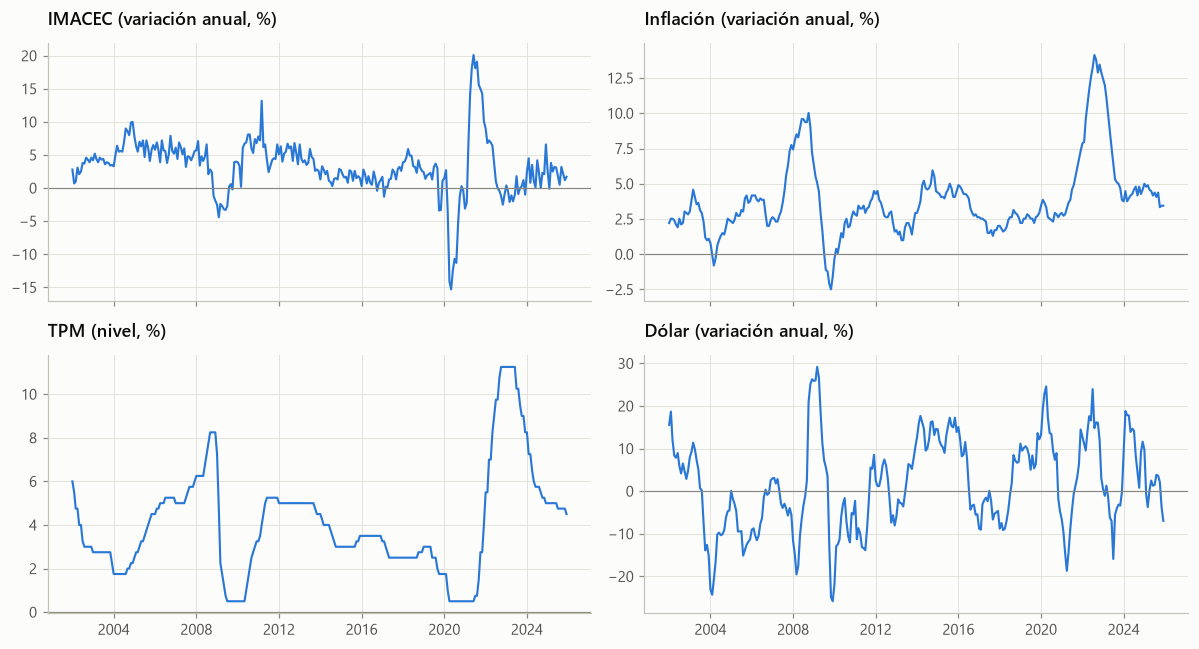

In [2]:
fig, ejes = plt.subplots(2, 2, figsize=(11, 6), sharex=True)
for ax, (columna, nombre) in zip(ejes.flat, VARIABLES.items()):
    ax.plot(datos_var.index, datos_var[columna], color=COLORES[0], linewidth=1.4)
    ax.axhline(0, color=TINTA_TENUE, linewidth=0.8)
    ax.set_title(nombre + (" (nivel, %)" if columna == "tpm" else " (variación anual, %)"))
fig.tight_layout()
plt.show()

## 2. ¿Cuántos rezagos?

Los criterios de información no coinciden. El BIC penaliza más la cantidad de parámetros y prefiere un modelo pequeño. El AIC prefiere trece rezagos, justo por encima de los doce meses de traslape de las variaciones anuales.

In [3]:
modelo = VAR(datos_var)
seleccion = modelo.select_order(15)
criterios = pd.DataFrame({k: v for k, v in seleccion.ics.items() if k in ("aic", "bic", "hqic")})
criterios.index.name = "rezagos"
print("Rezagos elegidos:", {k: int(v) for k, v in seleccion.selected_orders.items()})
criterios.loc[[1, 2, 3, 6, 12, 13, 14]]

Rezagos elegidos: {'aic': 13, 'bic': 2, 'hqic': 2, 'fpe': 13}


,aic,bic,hqic
rezagos,,,
1,0.332,0.597,0.439
2,-0.048,0.428,0.143
3,-0.087,0.601,0.189
6,-0.112,1.210,0.419
12,-0.144,2.448,0.896
13,-0.604,2.199,0.521
14,-0.576,2.438,0.634


## 3. Diagnóstico de los dos candidatos

In [4]:
# Un objeto de modelo por ajuste: statsmodels reutiliza nombres de parámetros entre ajustes.
candidatos = {"VAR(2)": VAR(datos_var).fit(2), "VAR(13)": VAR(datos_var).fit(13)}
diagnostico = {}
for nombre, ajuste in candidatos.items():
    fila = {"estable": ajuste.is_stable(), "parámetros por ecuación": 1 + ajuste.k_ar * ajuste.neqs}
    for columna, etiqueta in VARIABLES.items():
        fila[f"Ljung-Box {etiqueta}"] = acorr_ljungbox(ajuste.resid[columna], lags=[12])["lb_pvalue"].iloc[0]
    diagnostico[nombre] = fila
pd.DataFrame(diagnostico).T

,estable,parámetros por ecuación,Ljung-Box IMACEC,Ljung-Box Inflación,Ljung-Box TPM,Ljung-Box Dólar
VAR(2),True,9,0.000,0.000,0.114,0.000
VAR(13),True,53,0.796,0.517,0.990,0.661


**Lectura.** Los dos modelos son estables, pero solo el VAR(13) deja residuos sin autocorrelación, con p-valores de Ljung-Box sobre 5% en las cuatro ecuaciones. El VAR(2) no alcanza a capturar la autocorrelación mecánica de las variaciones anuales.

El precio del VAR(13) es alto: estima 53 parámetros por ecuación con menos de 300 observaciones. Un modelo tan grande describe bien el pasado, pero corre el riesgo de sobreajustar. La sección 6 pone a prueba justamente eso.

Para el análisis estructural se usa el VAR(13), porque sus residuos cumplen los supuestos.

## 4. Causalidad de Granger

Una variable causa en el sentido de Granger a otra si sus rezagos ayudan a predecirla, más allá de los rezagos de la propia variable. No implica causalidad económica.

In [5]:
var13 = candidatos["VAR(13)"]
filas = []
for destino in ("inflacion", "tpm"):
    for origen in VARIABLES:
        if origen != destino:
            prueba = var13.test_causality(destino, [origen], kind="f")
            filas.append({"causa": VARIABLES[origen], "efecto": VARIABLES[destino], "p-valor": prueba.pvalue})
granger = pd.DataFrame(filas)
granger["significativa al 5%"] = granger["p-valor"] < 0.05
granger

,causa,efecto,p-valor,significativa al 5%
0,IMACEC,Inflación,0.552,False
1,TPM,Inflación,0.067,False
2,Dólar,Inflación,0.845,False
3,IMACEC,TPM,0.002,True
4,Inflación,TPM,0.000,True
5,Dólar,TPM,0.000,True


**Lectura.** La TPM es la variable más fácil de anticipar: la inflación, la actividad y el dólar predicen sus movimientos. Eso refleja la función de reacción del Banco Central, que ajusta la tasa según esas tres variables. La inflación, en cambio, es difícil de anticipar con las demás: la TPM queda cerca del umbral de significancia, y ni la actividad ni el dólar aportan información adicional.

## 5. Respuestas a shocks

Las funciones impulso-respuesta muestran cómo reacciona cada variable ante un shock de una desviación estándar en otra. Los shocks se identifican con una descomposición de Cholesky con este orden: IMACEC, inflación, TPM y dólar. El orden supone que la actividad y la inflación no reaccionan a la TPM en el mismo mes, mientras el dólar reacciona a todo de inmediato. Es el supuesto habitual en VAR monetarios de economías pequeñas y abiertas.

Tamaño del shock de TPM: 0.26 puntos porcentuales
Tamaño del shock del dólar: 3.06 puntos de variación anual


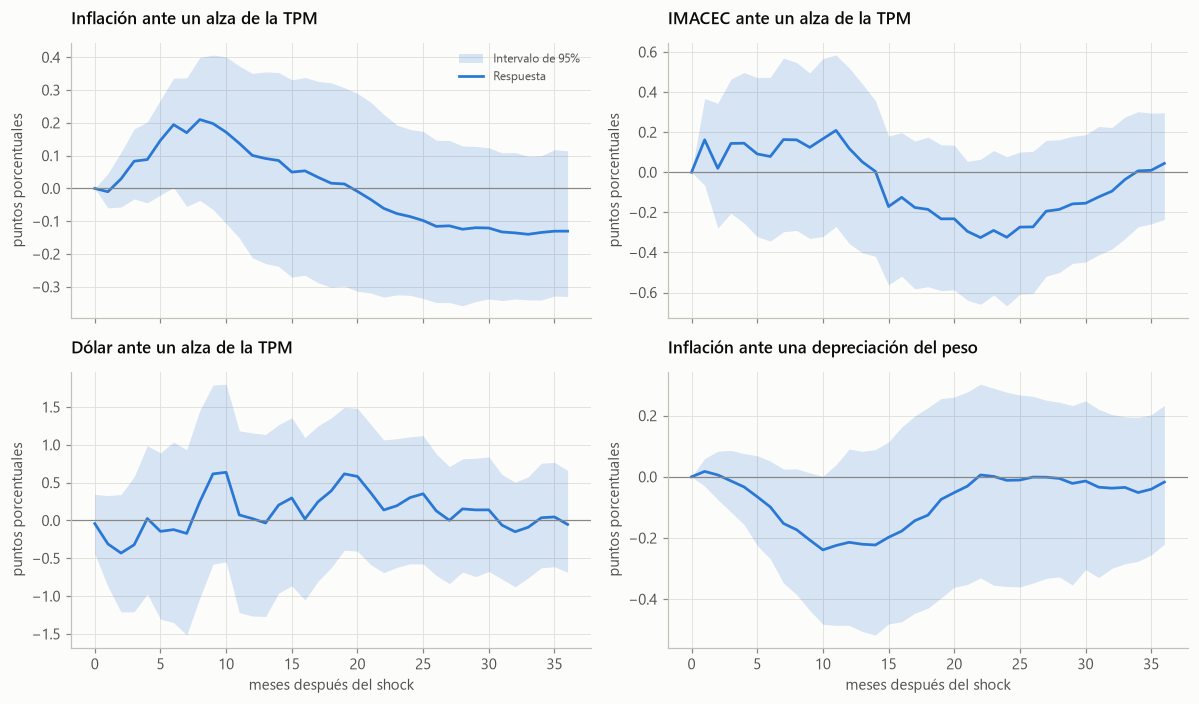

In [6]:
HORIZONTE_IRF = 36
irf = var13.irf(HORIZONTE_IRF)
inferior, superior = irf.errband_mc(orth=True, repl=500, signif=0.05, seed=1)
columnas = list(datos_var.columns)
sd_tpm = np.sqrt(var13.sigma_u.loc["tpm", "tpm"])
sd_dolar = np.sqrt(var13.sigma_u.loc["dolar", "dolar"])
print(f"Tamaño del shock de TPM: {sd_tpm:.2f} puntos porcentuales")
print(f"Tamaño del shock del dólar: {sd_dolar:.2f} puntos de variación anual")

paneles = [("inflacion", "tpm", "Inflación ante un alza de la TPM"),
           ("imacec", "tpm", "IMACEC ante un alza de la TPM"),
           ("dolar", "tpm", "Dólar ante un alza de la TPM"),
           ("inflacion", "dolar", "Inflación ante una depreciación del peso")]
meses = np.arange(HORIZONTE_IRF + 1)
fig, ejes = plt.subplots(2, 2, figsize=(11, 6.5), sharex=True)
for ax, (respuesta, impulso, titulo) in zip(ejes.flat, paneles):
    i, j = columnas.index(respuesta), columnas.index(impulso)
    ax.fill_between(meses, inferior[:, i, j], superior[:, i, j], color=COLORES[0], alpha=0.18, linewidth=0,
                    label="Intervalo de 95%")
    ax.plot(meses, irf.orth_irfs[:, i, j], color=COLORES[0], linewidth=1.8, label="Respuesta")
    ax.axhline(0, color=TINTA_TENUE, linewidth=0.8)
    ax.set_title(titulo, fontsize=11)
    ax.set_ylabel("puntos porcentuales")
for ax in ejes[1]:
    ax.set_xlabel("meses después del shock")
ejes[0, 0].legend(loc="upper right", fontsize=8)
fig.tight_layout()
fig.savefig(CARPETA / "figuras" / "impulso_respuesta.png", bbox_inches="tight")
plt.show()

In [7]:
def tabla_respuesta(respuesta, impulso, horizontes=(3, 6, 12, 18, 24, 36)):
    i, j = columnas.index(respuesta), columnas.index(impulso)
    return pd.DataFrame({"respuesta": irf.orth_irfs[list(horizontes), i, j],
                         "límite inferior": inferior[list(horizontes), i, j],
                         "límite superior": superior[list(horizontes), i, j]}, index=pd.Index(horizontes, name="mes"))

print("Inflación ante un alza de la TPM")
print(tabla_respuesta("inflacion", "tpm").round(3).to_string())
print("\nTPM ante un alza de la inflación")
print(tabla_respuesta("tpm", "inflacion").round(3).to_string())

Inflación ante un alza de la TPM
     respuesta  límite inferior  límite superior
mes                                             
3        0.083           -0.032            0.181
6        0.194            0.003            0.336
12       0.101           -0.212            0.351
18       0.016           -0.301            0.322
24      -0.086           -0.326            0.180
36      -0.130           -0.329            0.115

TPM ante un alza de la inflación
     respuesta  límite inferior  límite superior
mes                                             
3        0.182            0.095            0.257
6        0.246            0.114            0.359
12       0.269            0.012            0.436
18       0.229           -0.101            0.456
24       0.092           -0.229            0.323
36       0.014           -0.230            0.216


**Lectura.**

- **La TPM reacciona a la inflación.** Un shock inflacionario lleva a alzas de tasa que son significativas durante el primer año. Es la función de reacción esperable de un banco central con metas de inflación.
- **El price puzzle.** Tras un alza de la TPM, la inflación sube durante los primeros meses y solo después cae, aunque la caída no es significativa. Este resultado aparece en muchos VAR pequeños desde el trabajo de Sims en 1992. La explicación habitual es que el Banco Central sube la tasa cuando anticipa inflación, y el VAR no ve esa información, así que confunde la reacción con la causa.
- **Actividad y dólar, en la dirección esperada pero sin significancia.** El IMACEC cae un año y medio después del alza de tasas. El dólar baja levemente en los primeros meses, como predice la paridad de tasas de interés, pero luego se revierte. En ambos casos el intervalo incluye el cero.
- **Traspaso cambiario contraintuitivo.** Una depreciación del peso aparece asociada a menor inflación un año después. Lo más probable es que el shock del dólar esté capturando episodios de aversión global al riesgo, en que el peso se deprecia y la demanda interna se enfría al mismo tiempo.

Estos resultados muestran el límite de un VAR de cuatro variables: sirve para describir correlaciones dinámicas, pero no para medir con confianza el efecto causal de la política monetaria.

### Descomposición de la varianza del error de pronóstico

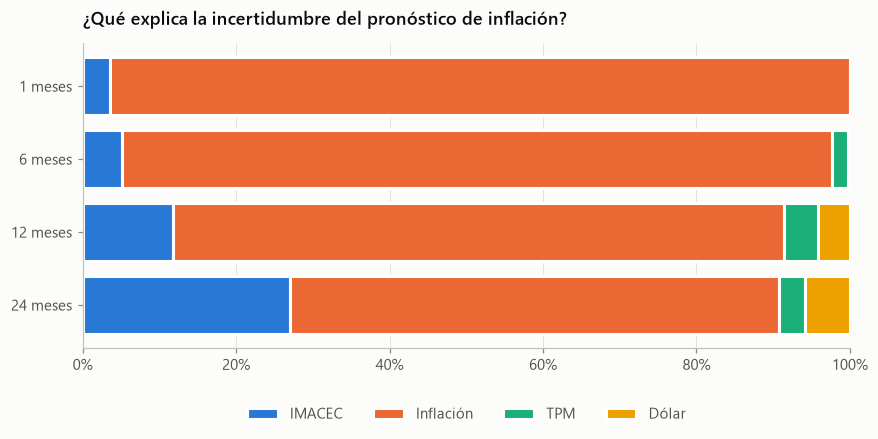

,IMACEC,Inflación,TPM,Dólar
meses,,,,
1,4%,96%,0%,0%
6,5%,93%,2%,0%
12,12%,80%,4%,4%
24,27%,64%,3%,6%


In [8]:
descomposicion = var13.fevd(24).decomp[columnas.index("inflacion")]
horizontes = [1, 6, 12, 24]
fevd = pd.DataFrame(descomposicion[[h - 1 for h in horizontes]], index=horizontes,
                    columns=[VARIABLES[c] for c in columnas])
fevd.index.name = "meses"

fig, ax = plt.subplots(figsize=(9, 3.6))
izquierda = np.zeros(len(fevd))
for k, columna in enumerate(fevd.columns):
    ax.barh([f"{h} meses" for h in fevd.index], fevd[columna], left=izquierda, color=COLORES[k],
            edgecolor="white", linewidth=2, label=columna)
    izquierda += fevd[columna].to_numpy()
ax.invert_yaxis()
ax.set_xlim(0, 1)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0%}"))
ax.set_title("¿Qué explica la incertidumbre del pronóstico de inflación?")
ax.legend(ncols=4, loc="upper center", bbox_to_anchor=(0.5, -0.15))
ax.grid(axis="y", visible=False)
plt.show()
fevd.style.format("{:.0%}")

A dos años, la mayor parte de la incertidumbre sobre la inflación viene de sus propios shocks, y la actividad explica una fracción relevante. La TPM y el dólar explican una parte pequeña. Esto es coherente con la débil causalidad de Granger de la sección anterior.

## 6. ¿Pronostica mejor el VAR que los modelos univariados?

Se repite la evaluación con origen móvil del notebook 02, con los mismos orígenes y el mismo objetivo: la inflación de los doce meses siguientes. En cada origen se reestiman el VAR(2), el VAR(13) y un autorregresivo univariado sobre la inflación anual. Los errores del SARIMA y del ETS se leen del archivo que guardó el notebook 02.

In [9]:
inflacion_anual = datos_var["inflacion"]
rezagos_ar = ar_select_order(inflacion_anual.loc[:"2011-12"], maxlag=15, ic="aic").ar_lags
print(f"Rezagos del autorregresivo, elegidos por AIC con datos hasta 2011: {len(rezagos_ar)}")

def var_con(rezagos):
    def pronosticar(historia, h):
        muestra = datos_var.loc[:historia.index[-1]]
        ajuste = VAR(muestra).fit(rezagos)
        return ajuste.forecast(muestra.to_numpy()[-rezagos:], h)[:, columnas.index("inflacion")]
    return pronosticar

def autorregresivo(historia, h):
    return AutoReg(historia, lags=rezagos_ar, trend="c").fit().forecast(h).to_numpy()

def paseo_aleatorio(historia, h):
    return np.repeat(historia.iloc[-1], h)

def meta_3(historia, h):
    return np.full(h, 3.0)

evaluacion = st.evaluar_origen_movil(
    inflacion_anual,
    {"VAR(2)": var_con(2), "VAR(13)": var_con(13), "AR univariado": autorregresivo,
     "Paseo aleatorio": paseo_aleatorio, "Meta 3%": meta_3},
    inicio="2012-01-01", horizonte=12)

errores = evaluacion[evaluacion["horizonte"] == 12].pivot(index="origen", columns="modelo", values="error")
univariados = pd.read_csv(CARPETA / "resultados" / "errores_12m_univariados.csv", index_col="origen", parse_dates=True)
errores = errores.join(univariados[["SARIMA", "ETS"]], how="inner")
print(f"{len(errores)} orígenes comunes, de {errores.index[0]:%m-%Y} a {errores.index[-1]:%m-%Y}")

Rezagos del autorregresivo, elegidos por AIC con datos hasta 2011: 13


157 orígenes comunes, de 12-2011 a 12-2024


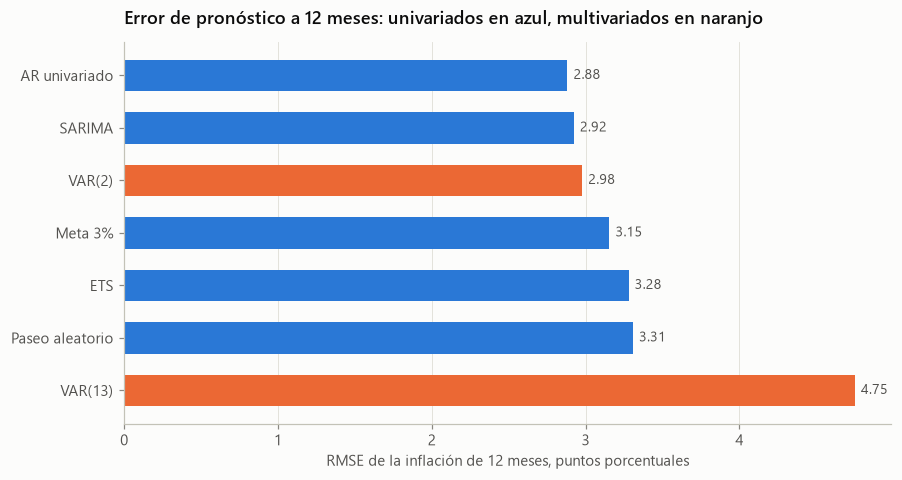

,RMSE total,RMSE hasta 2019
AR univariado,2.882,1.306
SARIMA,2.924,1.230
VAR(2),2.978,1.619
Meta 3%,3.155,1.181
ETS,3.279,2.387
Paseo aleatorio,3.308,1.638
VAR(13),4.751,2.775


In [10]:
def rmse_de(e):
    return np.sqrt((e ** 2).mean())

comparacion = pd.DataFrame({"RMSE total": errores.apply(rmse_de),
                            "RMSE hasta 2019": errores.loc[:"2019-06"].apply(rmse_de)}).sort_values("RMSE total")
multivariados = {"VAR(2)", "VAR(13)"}

fig, ax = plt.subplots(figsize=(9, 4.5))
colores = [COLORES[1] if m in multivariados else COLORES[0] for m in comparacion.index]
ax.barh(comparacion.index, comparacion["RMSE total"], color=colores, height=0.6)
for i, valor in enumerate(comparacion["RMSE total"]):
    ax.annotate(f"{valor:.2f}", (valor, i), xytext=(4, 0), textcoords="offset points", va="center", fontsize=9,
                color=TINTA_SECUNDARIA)
ax.invert_yaxis()
ax.set_xlabel("RMSE de la inflación de 12 meses, puntos porcentuales")
ax.set_title("Error de pronóstico a 12 meses: univariados en azul, multivariados en naranjo")
ax.grid(axis="y", visible=False)
fig.savefig(CARPETA / "figuras" / "comparacion_pronosticos.png", bbox_inches="tight")
plt.show()
comparacion

In [11]:
filas = {}
for rival in errores.columns:
    if rival != "VAR(13)":
        filas[f"VAR(13) contra {rival}"] = st.prueba_diebold_mariano(errores["VAR(13)"], errores[rival], 12)
    if rival not in ("VAR(2)", "VAR(13)", "SARIMA"):
        filas[f"VAR(2) contra {rival}"] = st.prueba_diebold_mariano(errores["VAR(2)"], errores[rival], 12)
filas["VAR(2) contra SARIMA"] = st.prueba_diebold_mariano(errores["VAR(2)"], errores["SARIMA"], 12)
dm = pd.DataFrame(filas).T
dm.columns = ["estadístico DM", "p-valor"]
dm["diferencia significativa al 5%"] = dm["p-valor"] < 0.05
dm

,estadístico DM,p-valor,diferencia significativa al 5%
VAR(13) contra AR univariado,1.915,0.057,False
VAR(2) contra AR univariado,0.458,0.648,False
VAR(13) contra Meta 3%,2.215,0.028,True
VAR(2) contra Meta 3%,-0.328,0.743,False
VAR(13) contra Paseo aleatorio,1.308,0.193,False
VAR(2) contra Paseo aleatorio,-0.710,0.479,False
VAR(13) contra VAR(2),1.651,0.101,False
VAR(13) contra SARIMA,2.147,0.033,True
VAR(13) contra ETS,1.227,0.222,False
VAR(2) contra ETS,-1.020,0.309,False


**Lectura.**

- **El VAR(13) es el peor pronosticador.** El modelo que mejor cumple los supuestos dentro de muestra tiene el mayor error fuera de muestra, y la diferencia con el SARIMA y con la meta del 3% es estadísticamente significativa. Es un caso típico de sobreajuste: 53 parámetros por ecuación capturan ruido del pasado que no se repite.
- **El VAR(2) queda en el grupo de los mejores, pero no gana.** Su error es similar al del SARIMA y del autorregresivo univariado. La información de actividad, TPM y dólar no mejora el pronóstico de inflación de forma significativa.
- **En tiempos normales, la meta sigue siendo el mejor pronóstico.** Hasta 2019 ningún modelo, univariado o multivariado, superó a la meta del 3%.

## 7. Conclusiones

1. **El VAR describe bien la reacción de la política monetaria.** La inflación predice los movimientos de la TPM, como corresponde a un banco central con metas de inflación.
2. **No sirve para medir el efecto de la política monetaria.** Las respuestas muestran el price puzzle y un traspaso cambiario con signo contrario al esperado. Identificar efectos causales requiere más información, como expectativas de inflación o precios de materias primas.
3. **Más variables no implican mejores pronósticos.** El VAR más completo pronostica peor que modelos univariados simples. Para pronosticar inflación en Chile, un SARIMA o la propia meta son referencias difíciles de superar.
4. **Elegir el modelo según el objetivo.** El AIC y los diagnósticos de residuos favorecen al VAR(13) para describir el pasado. El pronóstico fuera de muestra favorece modelos pequeños. En validación de modelos, ambas miradas son necesarias.

## 8. Limitaciones y extensiones

- **Variaciones anuales.** Usar el IMACEC en nivel desestacionalizado, disponible en la base del Banco Central con registro, permitiría trabajar con variaciones mensuales y un VAR más pequeño.
- **Identificación.** Un VAR con restricciones de signo o con variables externas, como el precio del cobre y la tasa de la Reserva Federal, podría resolver el price puzzle.
- **Estabilidad de parámetros.** La muestra incluye la crisis de 2008 y la pandemia. Un VAR con parámetros cambiantes en el tiempo capturaría mejor esos quiebres.